In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import qr, pinv
from scipy.linalg import solve_triangular

np.random.seed(42)

# LOESS
Рассмотрим обыкновенную линейную регрессию. Её формула:

$$y_i = f(x_i) + \epsilon_i,$$

где

$$f(x_i) = \beta_0 + \beta_1 \cdot x_i.$$

Однако рассмотрим данные следующего вида:

In [127]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)

<Axes: >

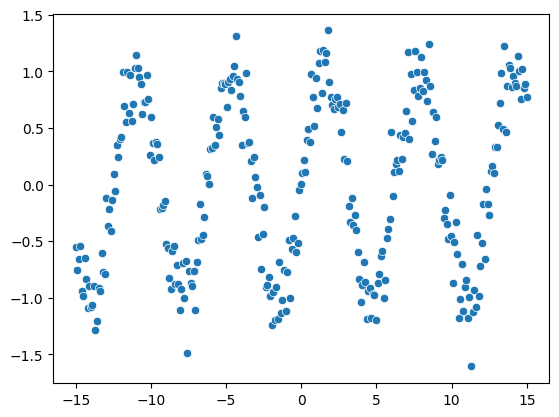

In [128]:
sns.scatterplot(x=x, y=y)

Попробуем обучить модель линейной модели на этих данных

<Axes: >

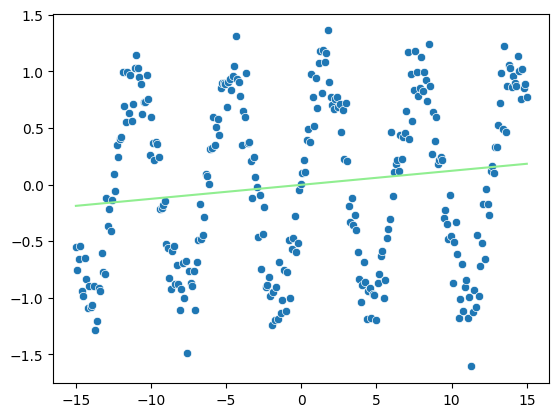

In [129]:
lin = LinearRegression().fit(x.reshape(-1, 1), y)
preds_lin = lin.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds_lin, color="lightgreen")

Кажется, что линейная модель никак не может выявить зависимость в данных. Одно из возможных решений - полиномиальная регрессия. Как думаете, какая степень полинома понадобится?

**Ответ:** Функция $\sin(x)$ на $[-15, 15]$ совершает $\approx 4{,}8$ полных периодов, что соответствует $\approx 10$ локальным экстремумам. Для полинома, который воспроизводит столько перегибов, нужна степень не меньше $\approx 10{-}11$. 

<Axes: >

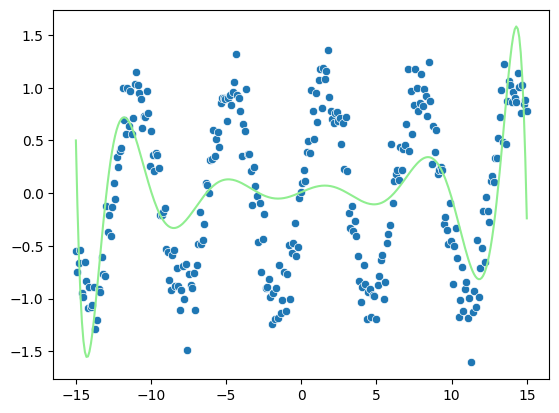

In [130]:
pipe = make_pipeline(PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1), y)
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")

Кажется, что для таких данных построить единую модель будет чрезвычайно сложно. Как можно решить такую проблему? Одно из решений - каким-то образом взвесить семплы, чтобы семплы ближе к переломам были более важны.

<Axes: >

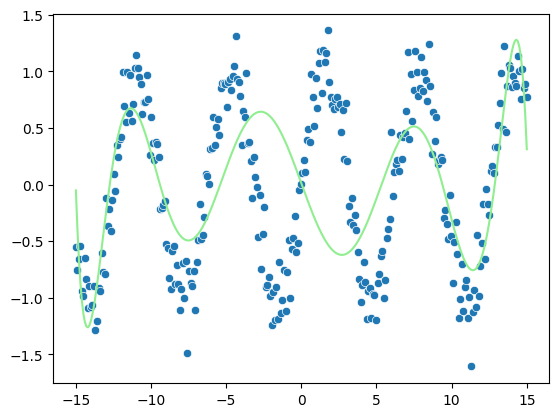

In [131]:
# Обучите с более высокой степенью
pipe = make_pipeline(PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1), y, linearregression__sample_weight=abs(x))
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")

Выглядит уже ближе. Однако как бы нам сделать процесс взвешивания автоматическим? Рассмотрим модель взвешенной регрессии.

## Ядровая регрессия Надарая–Уотсона

Рассмотрим непараметрическую постановку $y_i = f(x_i) + \varepsilon_i$, где $f$ не фиксируется заранее конечномерным набором параметров.

**Ядерная регрессия Надарая–Уотсона (NW)** в точке $x$ задаёт оценку $\hat f(x)$ как взвешенное среднее значений $y_i$.

Используем **трикубическое ядро**. Положим $u_i(x)=|x-x_i|/h$. Тогда
$$K_h(x-x_i)=\bigl(1-u_i(x)^3\bigr)_+^3\quad\text{при }u_i(x)<1,\qquad 0\ \text{ иначе}.$$

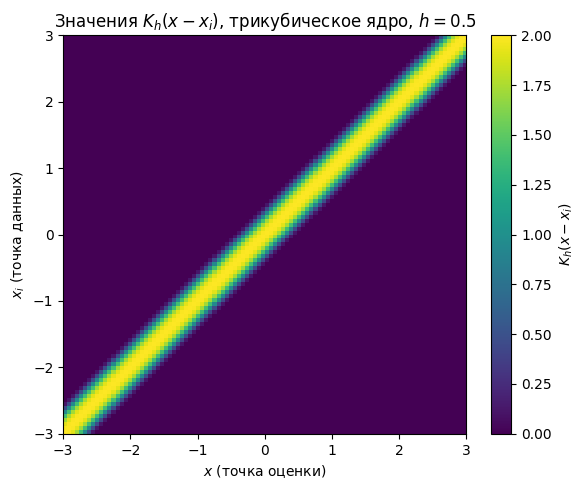

In [132]:
def tricubic_kernel_u(u: np.ndarray) -> np.ndarray:
    u = np.abs(u)
    out = np.zeros_like(u, dtype=float)
    m = u < 1.0
    # Решение: трикубическое ядро (1 - u^3)^3 там, где u < 1
    out[m] = (1 - u[m]**3)**3
    return out


n: int = 100
x_grid = np.linspace(-3.0, 3.0, n)
h: float = 0.5
X_i = x_grid[:, None]
X_j = x_grid[None, :]
diff_signed = (X_j - X_i) / h
K_mat = tricubic_kernel_u(diff_signed) / h

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    K_mat,
    origin="lower",
    extent=(x_grid.min(), x_grid.max(), x_grid.min(), x_grid.max()),
    aspect="auto",
    cmap="viridis",
)
ax.set_xlabel("$x$ (точка оценки)")
ax.set_ylabel("$x_i$ (точка данных)")
ax.set_title(f"Значения $K_h(x-x_i)$, трикубическое ядро, $h={h}$")
fig.colorbar(im, ax=ax, label="$K_h(x-x_i)$")
plt.tight_layout()
plt.show()

Оценка Надарая–Уотсона:
$$\hat{f}_{\mathrm{NW}}(x)=\frac{\sum_{i=1}^n K_h(x-x_i)\,y_i}{\sum_{i=1}^n K_h(x-x_i)}.$$

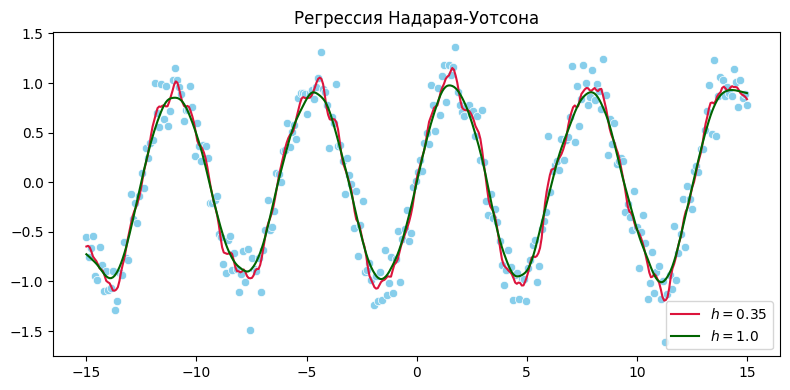

In [133]:
def nw_predict(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    h: float,
) -> np.ndarray:
    u = np.abs(x_query[:, None] - x_train[None, :]) / h
    # Решение: применяем трикубическое ядро к нормированным расстояниям
    w = tricubic_kernel_u(u)               # shape (n_query, n_train)
    s = w.sum(axis=1)                       # сумма весов для каждой точки запроса
    # Решение: взвешенная сумма y_train
    wy = w @ y_train                        # (n_query,)
    return np.where(s > 0, wy / s, np.nan)


h_narrow = 0.35
h_wide = 1.0
x_query = np.linspace(float(x.min()), float(x.max()), 400)
y_nw_n = nw_predict(x, y, x_query, h_narrow)
y_nw_w = nw_predict(x, y, x_query, h_wide)

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=x, y=y, ax=ax, color="skyblue")
sns.lineplot(x=x_query, y=y_nw_n, ax=ax, color="crimson", label=f"$h={h_narrow}$")
sns.lineplot(x=x_query, y=y_nw_w, ax=ax, color="darkgreen", label=f"$h={h_wide}$")
ax.legend()
ax.set_title("Регрессия Надарая-Уотсона")
plt.tight_layout()
plt.show()

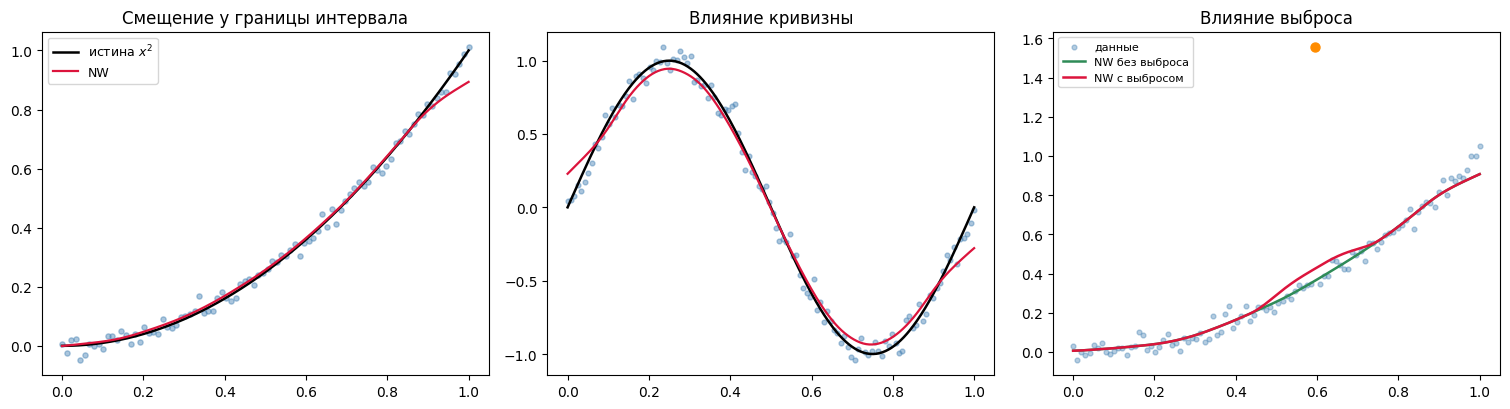

In [134]:
rng = np.random.default_rng(42)
x_edge = np.linspace(0.0, 1.0, 90)
y_edge = x_edge**2 + rng.normal(0.0, 0.025, size=x_edge.shape)
x_q01 = np.linspace(0.0, 1.0, 400)
h_edge: float = 0.18
nw_edge = nw_predict(x_edge, y_edge, x_q01, h_edge)

x_sin = np.linspace(0.0, 1.0, 120)
y_sin = np.sin(2 * np.pi * x_sin) + rng.normal(0.0, 0.06, size=x_sin.shape)
h_sin: float = 0.14
nw_sin = nw_predict(x_sin, y_sin, x_q01, h_sin)

x_out = np.linspace(0.0, 1.0, 100)
y_out_clean = x_out**2 + rng.normal(0.0, 0.03, size=x_out.shape)
outlier_idx = np.argmin(np.abs(x_out - 0.6))
y_out_with = y_out_clean.copy()
y_out_with[outlier_idx] += 1.2
h_out: float = 0.17
nw_out_clean = nw_predict(x_out, y_out_clean, x_q01, h_out)
nw_out_with = nw_predict(x_out, y_out_with, x_q01, h_out)

fig, (axb, axc, axd) = plt.subplots(1, 3, figsize=(15.2, 4.2))
axb.scatter(x_edge, y_edge, s=14, alpha=0.45, color="steelblue")
axb.plot(x_q01, x_q01**2, color="black", linewidth=1.8, label="истина $x^2$")
axb.plot(x_q01, nw_edge, color="crimson", linewidth=1.6, label="NW")
axb.set_title("Смещение у границы интервала")
axb.legend(loc="upper left", fontsize=9)
axc.scatter(x_sin, y_sin, s=12, alpha=0.45, color="steelblue")
axc.plot(x_q01, np.sin(2 * np.pi * x_q01), color="black", linewidth=1.8)
axc.plot(x_q01, nw_sin, color="crimson", linewidth=1.6, label="NW")
axc.set_title("Влияние кривизны")
axd.scatter(x_out, y_out_with, s=12, alpha=0.4, color="steelblue", label="данные")
axd.scatter(x_out[outlier_idx], y_out_with[outlier_idx], s=42, color="darkorange", zorder=4)
axd.plot(x_q01, nw_out_clean, color="seagreen", linewidth=1.8, label="NW без выброса")
axd.plot(x_q01, nw_out_with, color="crimson", linewidth=1.8, label="NW с выбросом")
axd.set_title("Влияние выброса")
axd.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Поэтому мы можем перейти к чуть более сложному методу: что если веса в каждой точке будут получаться не через простое взвешивание, а через полиномиальную (или линейную) регрессию?

Рассмотрим постановку задачи взвешенной полиномиальной регрессии:
$$\sum_i w_i(x_0)\,\bigl(y_i - (\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots)\bigr)^2 \rightarrow \min_{\beta}.$$

LOESS сочетает в себе простоту линейной (полиномиальной) регрессии с универсальностью непараметрических методов.

Реализуем метод локальной регрессии. Нам необходимо решить уравнение

$$W X \hat{\beta} = W y$$

(эквивалентно нормальным уравнениям $X^{\mathsf T} W X \hat{\beta} = X^{\mathsf T} W y$).

In [135]:
def solve(x, y, W, deg: int = 1):
    A = np.vander(x, N=1 + deg)  # матрица полиномиальных признаков (n, deg+1)

    # Решение: нормальные уравнения X^T W X и X^T W y
    V = A.T @ W @ A   
    Y = A.T @ W @ y   

    Q, R = qr(V)  
    p = solve_triangular(R, Q.T @ Y)  # R beta = Q^T Y
    return p

Напишем функцию, задающую нашу полосу пропускания и определяющую, какие точки в неё попали:

In [136]:
def get_span(x: np.ndarray, y: np.ndarray, x_target: float, k: int):
    """Returns distances, x in span and y in span."""
    # Решение: расстояния от каждой точки до x_target
    distance = np.abs(x - x_target)

    sorted_dist = np.sort(distance)
    ind = np.argsort(distance)

    ind_span = ind[:k]
    # Решение: выбираем x и y для k ближайших соседей
    x_span = x[ind_span]
    y_span = y[ind_span]
    # Решение: максимальное расстояние среди k ближайших (нужно для нормировки)
    delta_0 = sorted_dist[k - 1]  # расстояние до самого дальнего из k соседей

    u = distance[ind_span] / delta_0  # нормированные расстояния в [0, 1]
    return u, x_span, y_span, ind_span

И соберем финальную функцию.

In [137]:
def loess_tricub(x, y, k, deg):
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3
        W = np.diag(w)
        p = solve(x_span, y_span, W, deg=deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target
    return y_hat, x_space

Построим графики предсказаний для разных K.

error =  0.020837662359169264


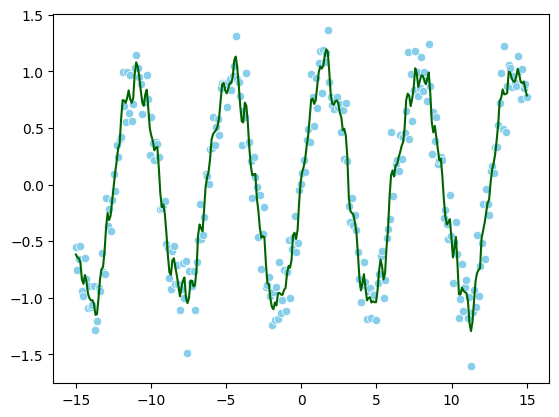

In [138]:
y_pred, x_pred = loess_tricub(x, y, k=5, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color='darkgreen')
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

error =  0.03758271258545015


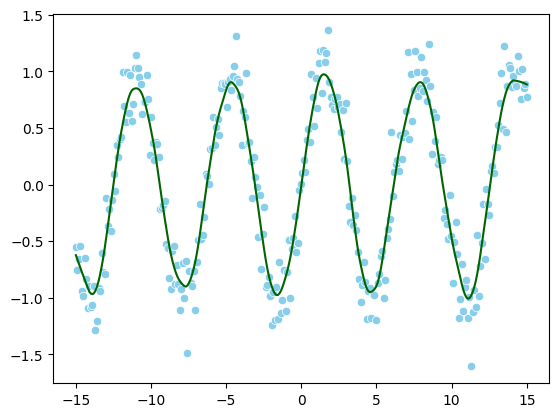

In [139]:
y_pred, x_pred = loess_tricub(x, y, k=20, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color='darkgreen')
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Чем больше k, тем более сглаженным получается решение. Реализуем выбор полосы пропускания через долю от размера датасета.

In [140]:
def get_k_relative(alpha: float, n: int):
    # Решение: число соседей как доля alpha от общего числа точек
    return max(int(np.ceil(alpha * n)), 2)

def loess_tricub_alpha(x, y, alpha, deg):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3
        W = np.diag(w)
        p = solve(x_span, y_span, W, deg=deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target

    return y_hat, x_space

error =  0.5084280660749575


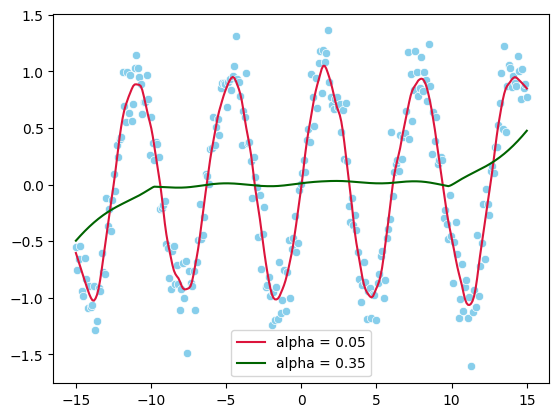

In [141]:
alpha_narrow = 0.05
alpha_wide = 0.35
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_narrow, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color='crimson', label=f"alpha = {alpha_narrow}")
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_wide, deg=1)
sns.lineplot(x=x_pred, y=y_pred, color='darkgreen', label=f"alpha = {alpha_wide}")
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Можно ли использовать другие функции в качестве весовых? Да, например, воспользуемся колоколообразным (гауссовым) ядром:

$$w^{(i)} = \exp\left( -\frac{(x^{(i)} - x)^2}{2\tau^2} \right).$$

Параметр $\tau$ контролирует, насколько быстро вес обучающего примера падает с увеличением расстояния до точки $x$. Вопрос: как меняется форма «колокола» при увеличении $\tau$?

**Ответ:** При увеличении $\tau$ колокол становится шире и более плоским: вес убывает медленнее с ростом расстояния, т.е. дальние точки получают больший относительный вклад в локальную регрессию. При $\tau \to \infty$ все точки получают практически одинаковый вес — модель вырождается в обычную МНК. При малом $\tau$ ядро очень острое: влияют лишь ближайшие соседи, кривая точно следует данным, но может переобучаться.

In [142]:
# Решение: функция loess с ядром как параметром
def loess(x, y, kernel, alpha, deg, **kernel_params):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_pred = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        # применяем выбранное ядро с дополнительными параметрами
        w = kernel(u, **kernel_params)
        W = np.diag(w)
        p = solve(x_span, y_span, W, deg=deg)
        y_pred[i] = np.polyval(p, x_target)
        x_space[i] = x_target

    return x_space, y_pred

Ещё один классический пример — гауссово (RBF) ядро на $\mathbb{R}^p$:
$$
k(x,x')=\sigma^2\exp\left(-\frac{1}{2\ell^2}\|x-x'\|^2\right).
$$
Параметр $\ell$ задаёт горизонтальный масштаб, $\sigma^2$ — вертикальный.

Такие ядра используют при задании ковариаций в гауссовских процессах и в методе опорных векторов (SVM).

Вообще разнообразных ядер достаточно много:

На нормированном расстоянии $u = d/\delta \in [0,1]$ часто используются:

- **трикуб**: $(1-u^3)^3$ при $u<1$;
- **Epanechnikov**: ${3 \over 4} (1-u^2)$;
- **биквадратное** (квадратичное): ${15 \over 16} (1-u^2)^2$;
- **триквадратное** (квадратичное): ${32 \over 33} (1-u^2)^3$;
- **треугольное**:  $(1-|u|)$;
- **равномерное**: $\mathbf{1}_{[0,1]}(u)$;
- **гауссово**: ${1 \over \sqrt{2\pi}} \exp(-{1 \over 2 } u^2)$; параметр $\tau$ задаёт ширину «колокола» (см. график справа).

Ниже слева — кривые нескольких ядер как функций $u$; справа — гауссово $K(d)$ при разных $\tau$. Затем — **сравнение тепловых карт** $K_h(x,x_i)$ на одной сетке и при одном $h$ для трикуба и гаусса: у трикуба носитель компактен, у гаусса — бесконечный хвост.

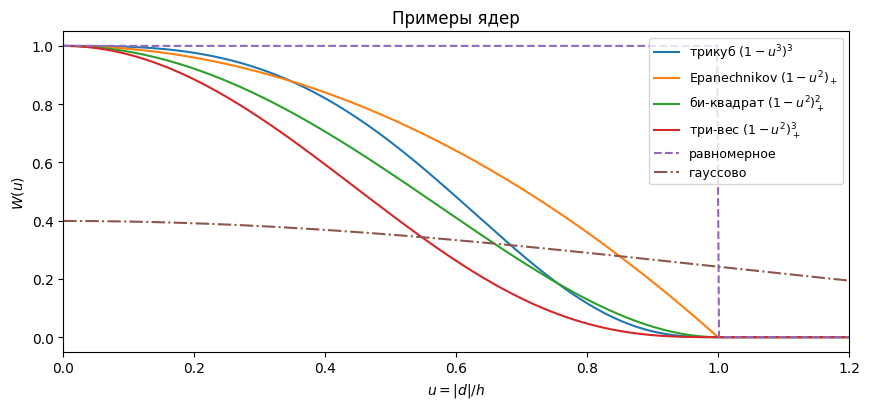

In [143]:
u_grid = np.linspace(0, 1.2, 400)
tricub = np.where((u_grid >= 0) & (u_grid < 1), (1 - u_grid**3) ** 3, 0.0)
epa = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2), 0.0)
bisq = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 2, 0.0)
triw = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 3, 0.0)
unif = np.where((u_grid >= 0) & (u_grid <= 1), 1.0, 0.0)
gau_std = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u_grid**2)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.2))
ax.plot(u_grid, tricub, label="трикуб $(1-u^3)^3$")
ax.plot(u_grid, epa, label="Epanechnikov $(1-u^2)_+$")
ax.plot(u_grid, bisq, label="би-квадрат $(1-u^2)_+^2$")
ax.plot(u_grid, triw, label="три-вес $(1-u^2)_+^3$")
ax.plot(u_grid, unif, linestyle="--", label="равномерное")
ax.plot(u_grid, gau_std, linestyle="-.", label="гауссово")
ax.set_xlabel("$u = |d|/h$")
ax.set_ylabel("$W(u)$")
ax.set_title("Примеры ядер")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1.2)
plt.tight_layout()
plt.show()

Задание: постройте тепловые карты для гауссовского, равномерного и любого другого ядер

In [144]:
def tricub_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, (1 - abs_dist**3) ** 3, 0.0)

def bell_kernel(dist: np.ndarray, tau: float = 0.5) -> np.ndarray:
    return np.exp(-(dist**2) / (2 * tau**2))

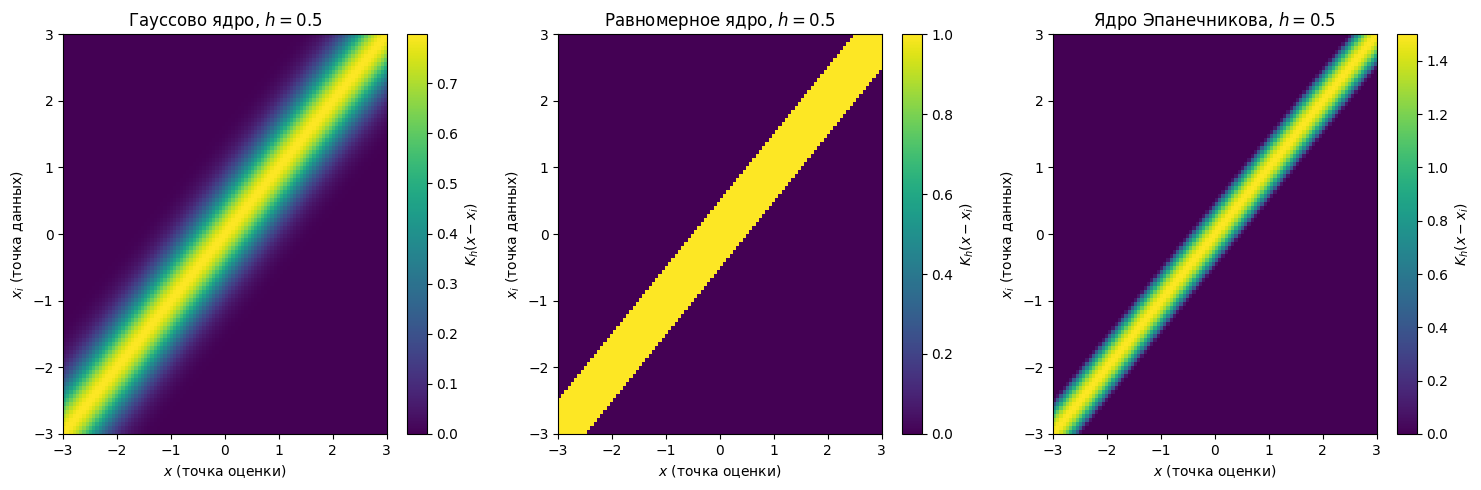

In [145]:
# Решение: тепловые карты для гауссовского, равномерного и ядра Эпанечникова

def gaussian_kernel_heatmap(dist: np.ndarray, h: float = 0.5) -> np.ndarray:
    """Гауссово ядро K_h(x - x_i) = (1/h) * phi((x - x_i)/h)"""
    u = dist / h
    return (1 / (h * np.sqrt(2 * np.pi))) * np.exp(-0.5 * u**2)

def uniform_kernel_heatmap(dist: np.ndarray, h: float = 0.5) -> np.ndarray:
    """Равномерное ядро: 1/(2h) при |x - x_i| < h, иначе 0"""
    return np.where(np.abs(dist) < h, 1.0 / (2 * h), 0.0)

def epanechnikov_kernel_heatmap(dist: np.ndarray, h: float = 0.5) -> np.ndarray:
    """Ядро Эпанечникова: (3/4)(1 - u^2) при |u| <= 1, иначе 0"""
    u = dist / h
    return np.where(np.abs(u) <= 1, (3 / (4 * h)) * (1 - u**2), 0.0)

n_hm = 100
x_hm = np.linspace(-3.0, 3.0, n_hm)
h_hm = 0.5
diff = x_hm[None, :] - x_hm[:, None]  # (x_query - x_i)

K_gauss = gaussian_kernel_heatmap(diff, h_hm)
K_unif  = uniform_kernel_heatmap(diff, h_hm)
K_epa   = epanechnikov_kernel_heatmap(diff, h_hm)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
extent = (x_hm.min(), x_hm.max(), x_hm.min(), x_hm.max())

for ax, K, title in zip(axes,
                         [K_gauss, K_unif, K_epa],
                         ["Гауссово ядро", "Равномерное ядро", "Ядро Эпанечникова"]):
    im = ax.imshow(K, origin="lower", extent=extent, aspect="auto", cmap="viridis")
    ax.set_xlabel("$x$ (точка оценки)")
    ax.set_ylabel("$x_i$ (точка данных)")
    ax.set_title(f"{title}, $h={h_hm}$")
    fig.colorbar(im, ax=ax, label="$K_h(x-x_i)$")

plt.tight_layout()
plt.show()

error =  0.03486464279750501


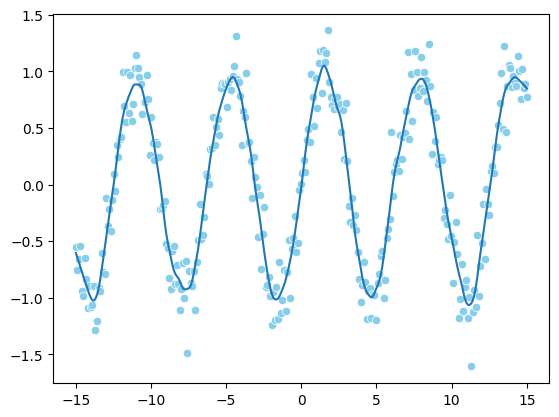

In [146]:
# calculate tricub loess with kernel as parameter
x_est, y_est = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est, y=y_est)
sns.scatterplot(x=x, y=y, color='skyblue')
print("error = ", mean_squared_error(y_true=y, y_pred=y_est))

error tricub =  0.03486464279750501
error bell   =  0.03087405446364361


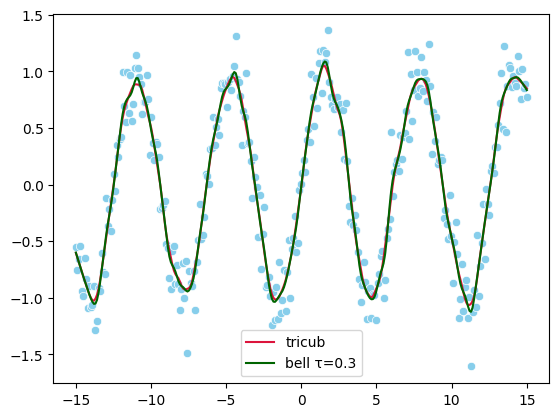

In [147]:
tau = 0.3
# Решение: loess с bell kernel
x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
x_est_bell, y_est_bell = loess(x, y, kernel=bell_kernel, alpha=0.05, deg=1, tau=tau)

sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", label="tricub")
sns.lineplot(x=x_est_bell,   y=y_est_bell,   color="darkgreen", label=f"bell τ={tau}")
plt.legend()
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_est_tricub))
print("error bell   = ", mean_squared_error(y_true=y, y_pred=y_est_bell))

Раз $tau$ регулирует, какой вклад будут давать дальние элементы, чего не было в обычном трикубическом ядре, нужен ли нам теперь параметр $\alpha$?

Ответ: При гауссовом ядре $\tau$ полностью управляет «шириной» влияния. При $\alpha = 1$ все $n$ точек участвуют в каждой локальной регрессии, а вклад дальних точек фактически обнуляется малым $\tau$. Это работает и позволяет установить $\alpha = 1$ и управлять только $\tau$. Тем не менее $\alpha < 1$ остаётся полезным по двум причинам: 1) вычислительная эффективность — локальная регрессия по $k \ll n$ точкам намного быстрее; 2) численная устойчивость — при слишком малом $\tau$ матрица весов становится почти нулевой, а при $\alpha < 1$ мы гарантированно работаем с $k$ точками с ненулевым весом.

error tricub =  0.03486464279750501
error bell   =  0.0310352057205


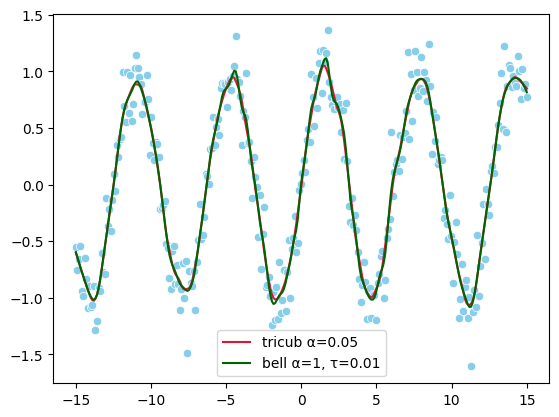

In [148]:
# set alpha=1 and find tau which gives similar results
x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", label="tricub α=0.05")
sns.scatterplot(x=x, y=y, color='skyblue')
tau = 0.01  # малый tau + alpha=1 даёт аналогичную узкую полосу
x_est_bell, y_est_bell = loess(x, y, kernel=bell_kernel, alpha=1, deg=1, tau=tau)
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", label=f"bell α=1, τ={tau}")
plt.legend()
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_est_tricub))
print("error bell   = ", mean_squared_error(y_true=y, y_pred=y_est_bell))

Если ошибки имеют симметричное распределение (с длинными хвостами) или есть выбросы, мы можем использовать более робастный LOESS.

Определим остатки:

$$
r_i = y_i - f(x_i).
$$

В нашем случае:

tricub tail share (robust z > 3) = 0.01
bell tail share (robust z > 3) = 0.006666666666666667
tricub excess kurtosis = 0.27818931834683447
bell excess kurtosis = 0.19921333396480634


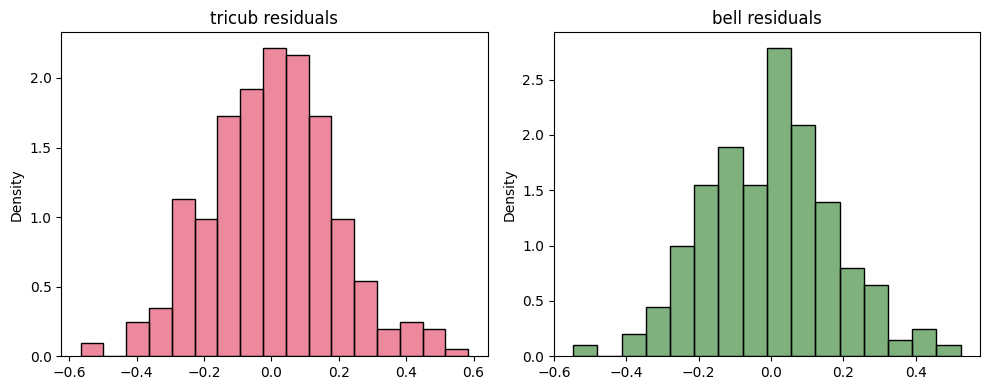

In [149]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[0])
axes[0].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[1])
axes[1].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)



Используем базовое ядро, заданное биквадратной функцией (bisquare):

$$
B(u) =
\begin{cases}
(1 - u^2)^2, & 0 \leq u < 1 \\
0, & \text{иначе.}
\end{cases}
$$

Пусть $m(r) = \mathrm{median}(|r|)$. Дополнительные веса тогда:

$$
\gamma_i = B\left(\frac{r_i}{6m}\right).
$$

Финальные веса принимают вид $\tilde{w}_i = \gamma_i\, w_i$.


In [150]:
def bicubic_kernel(dist):
    mask = dist < 1.
    return ((1 - dist ** 2) ** 2) * mask

def get_robust_weights(y, y_pred):
    # Решение: считаем остатки и медианное абсолютное отклонение
    residuals = y - y_pred
    s = np.median(np.abs(residuals))  # MAD (без нормировки 1.4826)
    multiplier = np.abs(residuals) / (6.0 * (s + 1e-12))
    multiplier = bicubic_kernel(multiplier)
    return multiplier

In [151]:
def loess_robust(x, y, kernel, alpha, deg, iterations, **kernel_params):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_pred = np.zeros(len(x))
    x_space = np.zeros_like(x)
    r_weights = np.ones(len(x))  # робастные веса, изначально все 1

    for iter_num in range(iterations):
        # Решение: итерация LOESS с учётом робастных весов
        for i, x_target in enumerate(x):
            u, x_span, y_span, ind_span = get_span(x, y, x_target, k)
            # комбинируем веса ядра и робастные веса
            w = kernel(u, **kernel_params) * r_weights[ind_span]
            W = np.diag(w)
            p = solve(x_span, y_span, W, deg=deg)
            y_pred[i] = np.polyval(p, x_target)
            x_space[i] = x_target
        # пересчитываем робастные веса по остаткам
        r_weights = get_robust_weights(y, y_pred)

    return x_space, y_pred

Построим данные, у которых действительно будут проблемы:

In [152]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)
y[5:10] -= 0.6
y[45:50] += 1.1
y[-30] += 1.
x[-45:-40] -= 0.1
x[145] += 1.1
x[-89:-80] -= 0.4

In [153]:
x_est_bell,   y_est_bell   = loess(x, y, kernel=bell_kernel,   alpha=0.05, deg=1, tau=0.3)
x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)

Посмотрим, какие результаты мы получили:

tricub tail share (robust z > 3) = 0.01
bell tail share (robust z > 3) = 0.01
tricub excess kurtosis = 1.0925518836862596
bell excess kurtosis = 0.9972206126456569


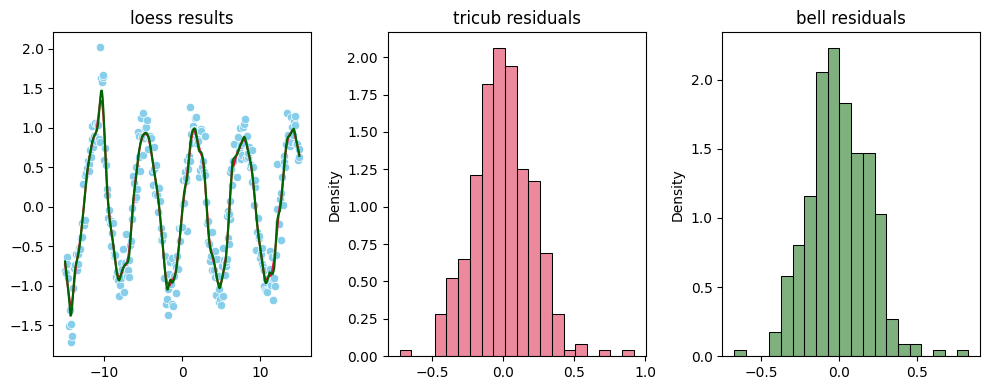

In [154]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[0])

sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", ax=axes[0])
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", ax=axes[0])
axes[0].set_title("loess results")
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[1])
axes[1].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[2])
axes[2].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)


tricub: tail share (|z|>3)=0.010, excess kurt=1.09
bell  : tail share (|z|>3)=0.010, excess kurt=1.00


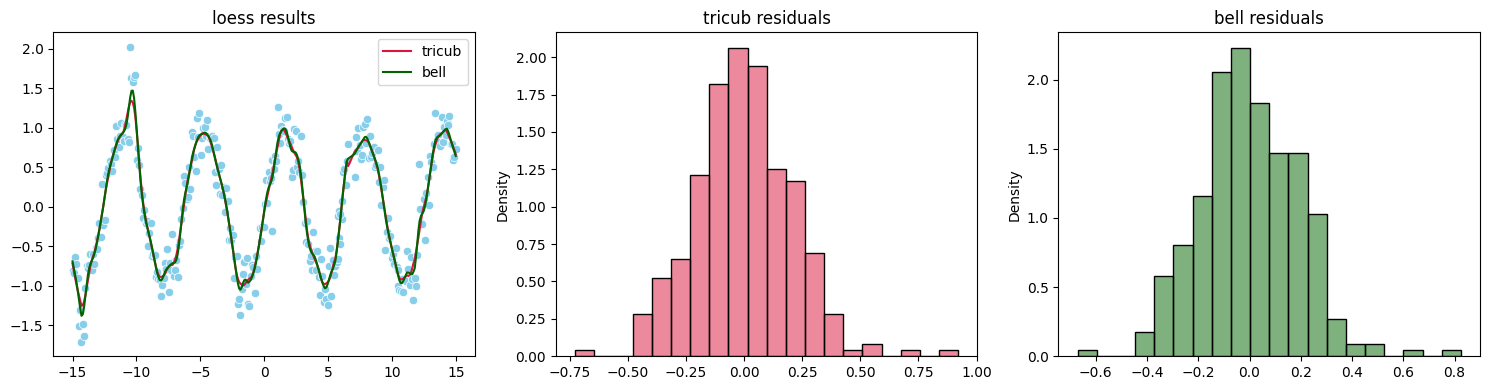

In [155]:
res_tricub = y - y_est_tricub
res_bell   = y - y_est_bell

def residual_stats(res, name):
    med = np.median(res)
    mad = np.median(np.abs(res - med)) + 1e-12
    rz  = np.abs(res - med) / (1.4826 * mad)
    c   = res - np.mean(res)
    m2  = np.mean(c**2) + 1e-12
    print(f"{name}: tail share (|z|>3)={np.mean(rz>3):.3f}, excess kurt={np.mean(c**4)/m2**2-3:.2f}")

residual_stats(res_tricub, "tricub")
residual_stats(res_bell,   "bell  ")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[0])
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson",   ax=axes[0], label="tricub")
sns.lineplot(x=x_est_bell,   y=y_est_bell,   color="darkgreen", ax=axes[0], label="bell")
axes[0].set_title("loess results")
axes[0].legend()
sns.histplot(res_tricub, stat="density", kde=False, color="crimson",   alpha=0.5, ax=axes[1])
axes[1].set_title("tricub residuals")
sns.histplot(res_bell,   stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[2])
axes[2].set_title("bell residuals")
plt.tight_layout()
plt.show()

Здесь уже видно, что есть тяжелые хвосты у остатков, попробуем применить робастную версию LOESS.

error robust =  0.05173687754391041


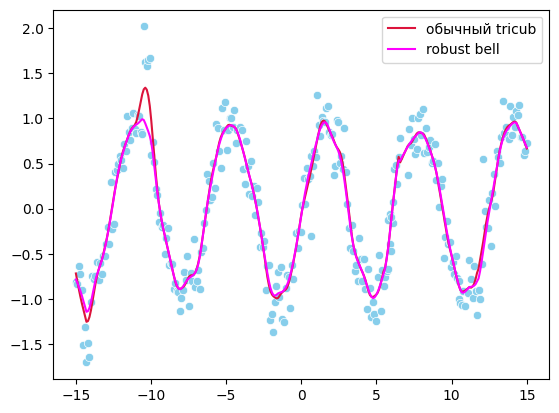

In [156]:
tau = 0.4
x_est_rob, y_est_rob = loess_robust(x, y, kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=tau)

sns.scatterplot(x=x, y=y, color='skyblue')
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson",  label="обычный tricub")
sns.lineplot(x=x_est_rob,    y=y_est_rob,    color="magenta",  label="robust bell")
plt.legend()
print("error robust = ", mean_squared_error(y_true=y, y_pred=y_est_rob))

Задание: попробуйте другие ядра и постройте loess для разных данных с ними. Для каких особенностей данных подходят разные ядра?

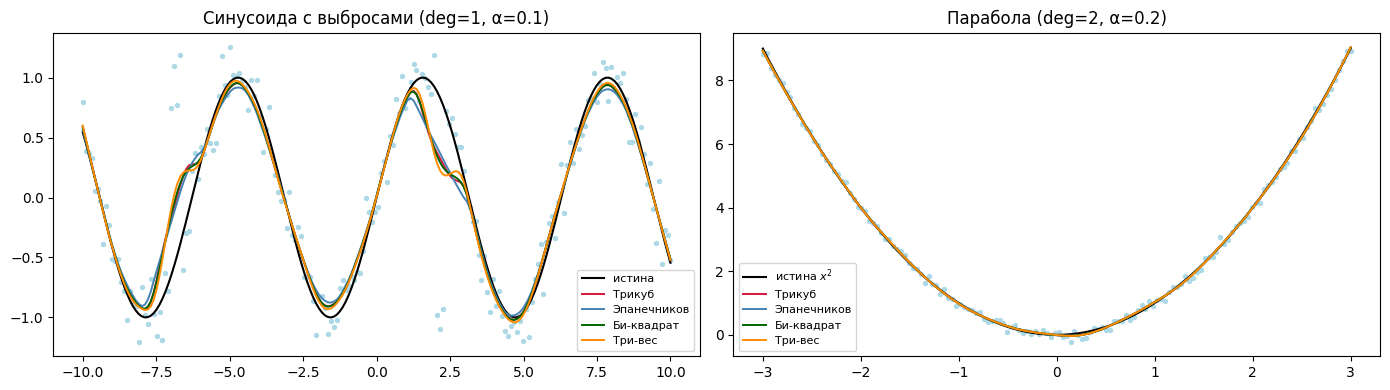

In [157]:
# Решение: реализация различных ядер

def epanechnikov_kernel(dist: np.ndarray) -> np.ndarray:
    """Ядро Эпанечникова: (3/4)(1-u^2) при |u|<=1, иначе 0.
    Оптимально по критерию минимальной асимптотической MSE среди компактных ядер.
    """
    abs_dist = np.abs(dist)
    return np.where(abs_dist <= 1, 0.75 * (1 - abs_dist**2), 0.0)


def bisquare_kernel(dist: np.ndarray) -> np.ndarray:
    """Би-квадратное ядро: (1-u^2)^2 при |u|<=1, иначе 0.
    Более плавное, чем Эпанечников — лучше для данных с плавными переходами.
    """
    abs_dist = np.abs(dist)
    return np.where(abs_dist <= 1, (1 - abs_dist**2)**2, 0.0)


def triweight_kernel(dist: np.ndarray) -> np.ndarray:
    """Три-весовое ядро: (35/32)(1-u^2)^3 при |u|<=1, иначе 0.
    Ещё более гладкое — подходит для данных без резких скачков.
    """
    abs_dist = np.abs(dist)
    return np.where(abs_dist <= 1, (35/32) * (1 - abs_dist**2)**3, 0.0)


# ── Эксперимент 1: синусоида с выбросами ────────────────────────────────────
np.random.seed(7)
x_exp = np.linspace(-10, 10, 200)
y_exp = np.sin(x_exp) + np.random.normal(0, 0.15, 200)
y_exp[30:34] += 1.5  # выбросы
y_exp[120:123] -= 1.8

kernels_exp = [
    (tricub_kernel,         "Трикуб",         "crimson"),
    (epanechnikov_kernel,   "Эпанечников",    "steelblue"),
    (bisquare_kernel,       "Би-квадрат",     "darkgreen"),
    (triweight_kernel,      "Три-вес",        "darkorange"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Синусоида с выбросами
axes[0].scatter(x_exp, y_exp, s=8, color="lightblue", zorder=1)
axes[0].plot(x_exp, np.sin(x_exp), color="black", lw=1.5, label="истина", zorder=2)
for k_fn, k_name, k_color in kernels_exp:
    xe, ye = loess(x_exp, y_exp, kernel=k_fn, alpha=0.1, deg=1)
    axes[0].plot(xe, ye, color=k_color, lw=1.4, label=k_name, zorder=3)
axes[0].set_title("Синусоида с выбросами (deg=1, α=0.1)")
axes[0].legend(fontsize=8)

# Квадратичная функция (пологая)
x_qd = np.linspace(-3, 3, 150)
y_qd = x_qd**2 + np.random.normal(0, 0.1, 150)
axes[1].scatter(x_qd, y_qd, s=8, color="lightblue", zorder=1)
axes[1].plot(x_qd, x_qd**2, color="black", lw=1.5, label="истина $x^2$", zorder=2)
for k_fn, k_name, k_color in kernels_exp:
    xe, ye = loess(x_qd, y_qd, kernel=k_fn, alpha=0.2, deg=2)
    axes[1].plot(xe, ye, color=k_color, lw=1.4, label=k_name, zorder=3)
axes[1].set_title("Парабола (deg=2, α=0.2)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Вывод:

Трикубическое:
  Хороший выбор по умолчанию. Компактный носитель + плавный спад.

Эпанечникова:
  Оптимально по MSE теоретически. Чуть «жёстче» на краях полосы.

Би-квадрат (bisquare):
  Более мягкое убывание, чем у Эпанечникова. Хорошо для плавных
  монотонных зависимостей.

Три-весовое (triweight):
  Самое мягкое компактное ядро: сильнее сглаживает, но теряет
  детали.

Гауссово (bell):
  Нет компактного носителя — каждая точка влияет на всю кривую.


Рассмотрим и уже знакомую нам задачу предсказания стоимости.

In [158]:
data_path = "D:\\data\\ml"
data = pd.read_csv("realestate.txt", sep="\t")

data = data[["SalePrice", "SqFeet", "Lot"]]
data = np.log(data)
X_train, X_test, y_train, y_test = train_test_split(data[["SqFeet"]], data["SalePrice"])

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_train)
loess_x, loess_y = loess_robust(
    X_train.values.astype(float).ravel(),
    y_train.values.astype(float).ravel(),
    kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=0.4
)
loess_x_naive, loess_y_naive = loess(
    X_train.values.astype(float).ravel(),
    y_train.values.astype(float).ravel(),
    kernel=bell_kernel, alpha=0.05, deg=1, tau=0.4
)

Linear Regression error: 0.049031461148086666
LOESS error: 0.041098579755357814


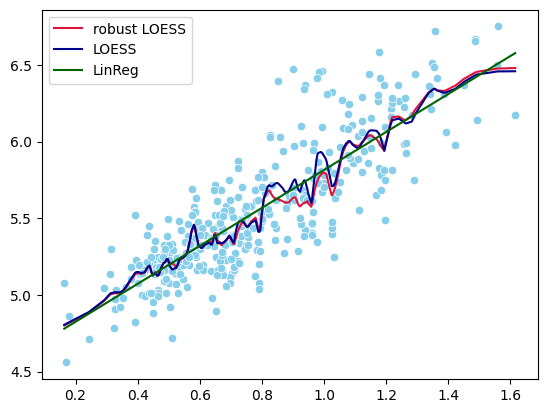

In [159]:
sns.lineplot(x=loess_x,       y=loess_y,       color="crimson",  label="robust LOESS")
sns.lineplot(x=loess_x_naive, y=loess_y_naive, color='darkblue', label="LOESS")
sns.lineplot(x=X_train.values.astype(float).ravel(), y=preds.ravel(), color='darkgreen', label="LinReg")
sns.scatterplot(x=X_train.values.astype(float).ravel(), y=y_train.values.astype(float).ravel(), color='skyblue')
plt.legend()
print("Linear Regression error:", mean_squared_error(y_train.values.astype(float).ravel(), preds))
print("LOESS error:",             mean_squared_error(y_train.values.astype(float).ravel(), loess_y_naive))

## KDE

В LOESS ядро задаёт веса точек при локальной регрессии. В **ядерной оценке плотности (KDE)** ядро задаёт форму вклада каждой наблюдаемой точки в оценку **плотности** $f(x)$ по выборке $X_1,\ldots,X_n$:

$\hat{f}(x)=\frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x-X_i}{h}\right)$. 

В `sklearn.neighbors.KernelDensity` доступно несколько видов ядер, см. [документацию](https://scikit-learn.org/stable/modules/density.html).  При этом KDE реализовано и в skipy со statsmodels, причем вы можете уыидеть, что они содержат методы для поиска наилучших параметров.

Построим KDE для остатков линейной регрессии на обучающей выборке, чтобы связать оценку плотности с уже построенной линейной моделью.

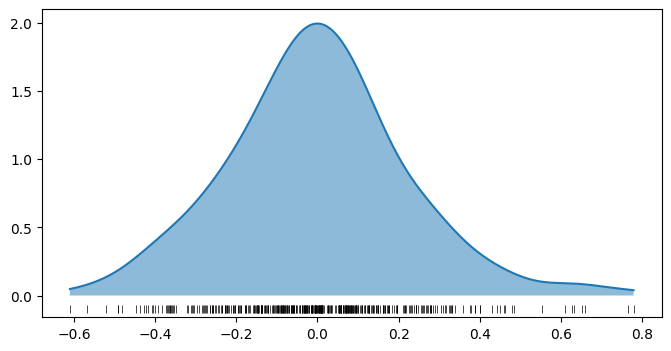

In [160]:
from sklearn.neighbors import KernelDensity

residuals = y_train.values.astype(float).ravel() - preds.ravel()
n = len(residuals)
bw = 1.06 * residuals.std(ddof=1) * (n ** (-0.2))
x_d = np.linspace(residuals.min(), residuals.max(), 500)
kde = KernelDensity(bandwidth=bw, kernel="gaussian")
kde.fit(residuals[:, None])
density = np.exp(kde.score_samples(x_d[:, None]))
fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_d, density, alpha=0.5)
ax.plot(x_d, density)
ax.plot(residuals, np.full_like(residuals, -density.max() * 0.05), "|k", markeredgewidth=0.5)
ax.set_ylim(bottom=-density.max() * 0.08)
plt.show()

Рассмотрим, возможно, более интересную задачу - попробуем отрисовать ареалы двух видов животных - ленивцев и лесных хомячков.

In [161]:
from sklearn.datasets import fetch_species_distributions

data_sp = fetch_species_distributions()
latlon = np.vstack([data_sp.train['dd lat'], data_sp.train['dd long']]).T
species = np.array([d.decode('ascii').startswith('micro') for d in data_sp.train['species']], dtype='int')

In [162]:
y_min, y_max = data_sp.train['dd lat'].min(),  data_sp.train['dd lat'].max()
x_min, x_max = data_sp.train['dd long'].min(), data_sp.train['dd long'].max()

In [163]:
def construct_grids(batch):
    xmin = batch.x_left_lower_corner + batch.grid_size
    xmax = xmin + batch.Nx * batch.grid_size

    ymin = batch.y_left_lower_corner + batch.grid_size
    ymax = ymin + batch.Ny * batch.grid_size

    xgrid = np.arange(xmin, xmax, batch.grid_size)
    ygrid = np.arange(ymin, ymax, batch.grid_size)

    return (xgrid, ygrid)

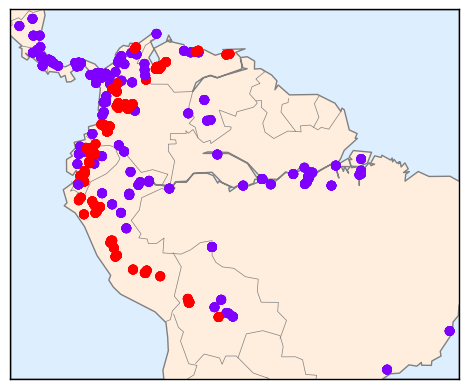

In [164]:
from mpl_toolkits.basemap import Basemap

# plot coastlines with basemap
m = Basemap(projection='cyl', resolution='c',
            llcrnrlat=y_min - 1, urcrnrlat=y_max + 1,
            llcrnrlon=x_min -1, urcrnrlon=x_max + 1)
m.drawmapboundary(fill_color='#DDEEFF')
m.fillcontinents(color='#FFEEDD')
m.drawcoastlines(color='gray', zorder=2)
m.drawcountries(color='gray', zorder=2)

# plot locations
m.scatter(latlon[:, 1], latlon[:, 0], zorder=3,
          c=species, cmap='rainbow', latlon=True);

К сожалению, это не дает хорошего представления о плотности вида, поскольку точки ареала вида могут перекрываться.

Давайте воспользуемся ядерной оценкой плотности, чтобы показать это распределение более понятным способом: как плавное указание плотности на карте. Поскольку система координат здесь лежит на сферической поверхности, а не на плоской плоскости, мы будем использовать метрику расстояния haversinus, которая будет правильно представлять расстояния на искривленной поверхности.


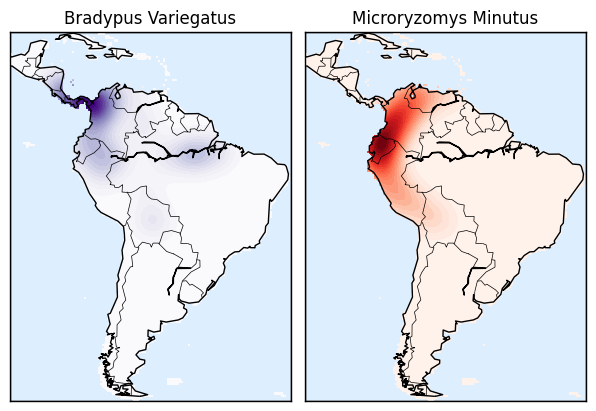

In [165]:
# Set up the data grid for the contour plot

xgrid, ygrid = construct_grids(data_sp)

X, Y = np.meshgrid(xgrid[::5], ygrid[::5][::-1])

land_reference = data_sp.coverages[6][::5, ::5]
land_mask = (land_reference > -9999).ravel()
xy = np.vstack([Y.ravel(), X.ravel()]).T
xy = np.radians(xy[land_mask])

# Create two side-by-side plots
fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05)
species_names = ['Bradypus Variegatus', 'Microryzomys Minutus']
cmaps = ['Purples', 'Reds']

for i, axi in enumerate(ax):
    axi.set_title(species_names[i])

    # plot coastlines with basemap
    m = Basemap(projection='cyl', llcrnrlat=Y.min(),
                urcrnrlat=Y.max(), llcrnrlon=X.min(),
                urcrnrlon=X.max(), resolution='c', ax=axi)
    m.drawmapboundary(fill_color='#DDEEFF')
    m.drawcoastlines()
    m.drawcountries()

    # construct a spherical kernel density estimate of the distribution
    # use metric='haversine'
    kde = KernelDensity(bandwidth=0.05, kernel="gaussian", metric='haversine') #
    # fit kde, don't forget to convert coords to radians
    kde.fit(np.radians(latlon[species == i]))

    # evaluate only on the land: -9999 indicates ocean
    Z = np.full(land_mask.shape[0], -9999.0)
    Z[land_mask] = np.exp(kde.score_samples(xy)) # exp of kde result
    Z = Z.reshape(X.shape)

    # plot contours of the density
    levels = np.linspace(0, Z.max(), 25)
    axi.contourf(X, Y, Z, levels=levels, cmap=cmaps[i])

Мы видим, что география видов действительно отличается, при этом можно видеть, где сконцентрировано больше всего особей. Так, даже сейчас мы можем попробовать вывести какие-то правила определеняи видов, и это без обучения!

Задание: напишите функцию KDE вручную, опробуйте на каком-нибудь датасете.

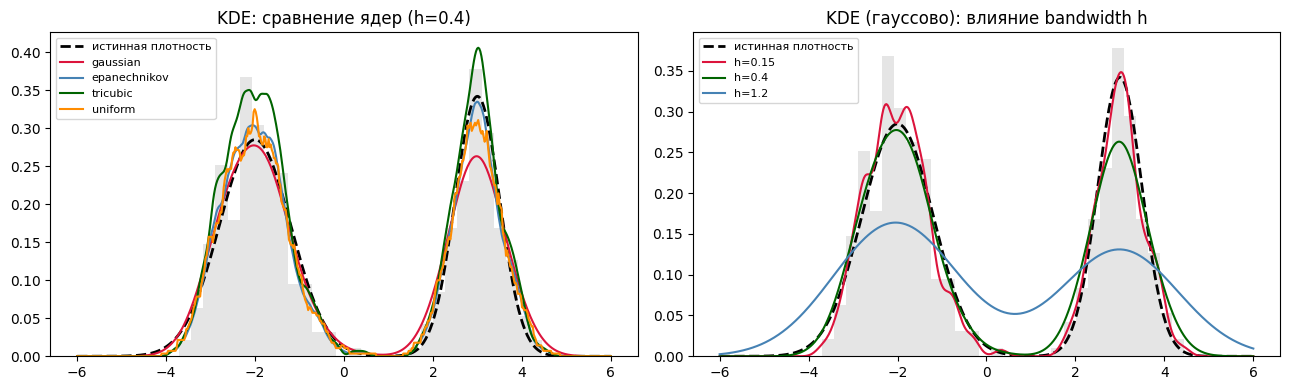

Максимальное отклонение от sklearn KDE: 1.94e-15

Наблюдения:
- При малом h оценка шумная.
- При большом h оценка сглажена.
- Оптимальное h хорошо восстанавливает смесь двух гауссиан.
- Все компактные ядра (Эпанечников, три-куб, равномерное) дают схожую точность
  при подходящем h, гауссово ядро немного лучше для гладких распределений.



In [166]:
# Решение: ручная реализация KDE

def kde_manual(
    X_train: np.ndarray,
    x_query: np.ndarray,
    h: float,
    kernel: str = "gaussian",
) -> np.ndarray:
    """
    Ядерная оценка плотности вручную.

    Parameters
    ----------
    X_train : (n,) — обучающая выборка
    x_query : (m,) — точки, в которых оцениваем плотность
    h       : ширина окна (bandwidth)
    kernel  : 'gaussian' | 'epanechnikov' | 'tricubic' | 'uniform'

    Returns
    -------
    density : (m,) — оценка плотности в точках x_query
    """
    n = len(X_train)
    # матрица нормированных расстояний u_{ji} = (x_j - X_i) / h
    u = (x_query[:, None] - X_train[None, :]) / h  # (m, n)

    if kernel == "gaussian":
        K = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)
    elif kernel == "epanechnikov":
        K = np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)
    elif kernel == "tricubic":
        K = np.where(np.abs(u) < 1, (1 - np.abs(u)**3)**3, 0.0)
    elif kernel == "uniform":
        K = np.where(np.abs(u) <= 1, 0.5, 0.0)
    else:
        raise ValueError(f"Unknown kernel: {kernel}")

    # усредняем по обучающим точкам и нормируем на h
    density = K.mean(axis=1) / h
    return density


# ── Эксперимент: смесь двух гауссиан ────────────────────────────────────────
rng_kde = np.random.default_rng(42)
sample1 = rng_kde.normal(-2, 0.8, 200)
sample2 = rng_kde.normal( 3, 0.5, 150)
X_kde   = np.concatenate([sample1, sample2])

x_eval = np.linspace(-6, 6, 500)

# Истинная плотность (смесь гауссиан)
true_density = (200 * (1/(0.8*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_eval+2)/0.8)**2) +
                150 * (1/(0.5*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_eval-3)/0.5)**2)) / 350

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Левый: сравнение ядер при фиксированном h
h_fixed = 0.4
axes[0].plot(x_eval, true_density, "k--", lw=2, label="истинная плотность")
for kname, kcolor in [("gaussian", "crimson"), ("epanechnikov", "steelblue"),
                      ("tricubic", "darkgreen"), ("uniform", "darkorange")]:
    d = kde_manual(X_kde, x_eval, h=h_fixed, kernel=kname)
    axes[0].plot(x_eval, d, color=kcolor, lw=1.5, label=kname)
axes[0].hist(X_kde, bins=30, density=True, alpha=0.2, color="gray")
axes[0].set_title(f"KDE: сравнение ядер (h={h_fixed})")
axes[0].legend(fontsize=8)

# Правый: гауссово ядро при разных h
axes[1].plot(x_eval, true_density, "k--", lw=2, label="истинная плотность")
for h_val, h_color in [(0.15, "crimson"), (0.4, "darkgreen"), (1.2, "steelblue")]:
    d = kde_manual(X_kde, x_eval, h=h_val, kernel="gaussian")
    axes[1].plot(x_eval, d, color=h_color, lw=1.5, label=f"h={h_val}")
axes[1].hist(X_kde, bins=30, density=True, alpha=0.2, color="gray")
axes[1].set_title("KDE (гауссово): влияние bandwidth h")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Сравнение с sklearn ──────────────────────────────────────────────────────
kde_sk = KernelDensity(bandwidth=0.4, kernel="gaussian")
kde_sk.fit(X_kde[:, None])
d_sk = np.exp(kde_sk.score_samples(x_eval[:, None]))
d_manual = kde_manual(X_kde, x_eval, h=0.4, kernel="gaussian")

max_diff = np.max(np.abs(d_sk - d_manual))
print(f"Максимальное отклонение от sklearn KDE: {max_diff:.2e}")

print("""
Наблюдения:
- При малом h оценка шумная.
- При большом h оценка сглажена.
- Оптимальное h хорошо восстанавливает смесь двух гауссиан.
- Все компактные ядра (Эпанечников, три-куб, равномерное) дают схожую точность
  при подходящем h, гауссово ядро немного лучше для гладких распределений.
""")